# St. Louis Tree Canopy & Income Equity Analysis

This notebook analyzes the relationship between median household income and tree canopy coverage across census tracts in St. Louis City, Missouri. The goal is to identify **priority zones** (tracts with both low income and low canopy coverage) to help guide community-led planting initiatives.

St. Louis is one of the most well-documented examples of redlining in the US. Because trees take decades to grow, neighborhoods that experienced systematic disinvestment in the mid-20th century often still show lower canopy coverage today. This analysis asks whether that pattern is visible in current data.

## 1. Environment Setup

Import all required libraries and load environment variables. The NHGIS API key is stored as an environment variable (`IPUMS_API_KEY`) rather than hardcoded for security.

In [43]:
# Import statements and environment variables
from ipumspy import AggregateDataExtract, NhgisDataset, IpumsApiClient
from rasterio.mask import mask as geom_mask
from scipy.stats import spearmanr
from zipfile import ZipFile
from pygris import tracts
import geopandas as gpd
import rasterstats
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
import os 



IPUMS_API_KEY = os.getenv('IPUMS_API_KEY') # Need to configure IPUMS API KEY in environmental variables prior to running
ipums = IpumsApiClient(IPUMS_API_KEY)

## 2. Fetch Census Tract Data via NHGIS API

We use `ipumspy` to pull tract-level median household income (ACS Table B19013) for St. Louis City, Missouri.

**Geographic identifiers:**
- State FIPS: `29` (Missouri). Using '290' for the API
- County FIPS: `510` (St. Louis City — a county-equivalent independent city, separate from St. Louis County which is FIPS 189)

**Dataset:** `2020_2024_ACS5a` (2020–2024 ACS 5-Year Estimates, Block Groups & Larger Areas)

The extract is submitted programmatically so this analysis is fully reproducible.

In [ ]:
target_dir = os.path.join("data", "raw")
os.makedirs(target_dir, exist_ok=True)

# NHGIS dataset parameters
dataset = NhgisDataset(
    name="2020_2024_ACS5a",
    data_tables=["B19013"],
    geog_levels=["tract"]
)
# IPUMS Extract parameters, including NHGIS dataset params
extract = AggregateDataExtract(
    collection="nhgis",
    description="2024 Median Household Income by Census Tract for Missouri",
    datasets=[dataset],
    geographic_extents=['290']
    )

# Submitting and downloading the extract
ipums.submit_extract(extract)
print("Extract submitted to IPUMS.")
ipums.wait_for_extract(extract)
print("Please wait. Extract download in progress...")
ipums.download_extract(extract, download_dir=target_dir)
print(f"Extract completed! ZIP file(s) saved to {target_dir}")



Using FIPS code '29' for input 'MO'
Using FIPS code '510' for input 'St. Louis City'


<Axes: >

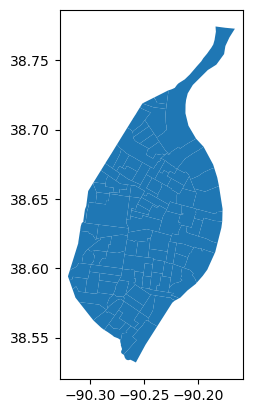

In [ ]:
# Pulling St. Louis, Missouri Census Tract boundaries using pygris
stl_census = pygris.tracts(state = "MO", county = "St. Louis City", year=2020)
stl_census.plot() # For visual verification

In [ ]:
# Extract data from zip file
fname = r"data\raw\nhgis0003_csv.zip"
ZipFile(fname).namelist()
#gpd.read_file(fname)

csv_path = '/nhgis0003_csv/nhgis0003_ds272_20245_tract.csv'
gpd.read_file(csv_path)

DataSourceError: nhgis0003_csv/nhgis0003_ds272_20245_tract.csv: No such file or directory

## 3. Load and Filter Census Tract Geometries

Load the downloaded NHGIS shapefile into geopandas and filter to St. Louis City tracts only (county FIPS 510). We also check and set the CRS here.

For any area calculations we reproject to a metric CRS. Missouri State Plane East (EPSG to be confirmed via epsg.io) is appropriate for St. Louis.

In [ ]:
# Load shapefile, filter to county 510, check CRS goes here

## 4. Load and Clip NLCD Tree Canopy Raster

The NLCD tree canopy cover raster is a national dataset at 30-meter resolution. To save memory and processing time, we clip it to the bounding box of our St. Louis City tracts before doing anything else.

We do **not** reproject the raster. Reprojecting a raster requires resampling pixel values, which introduces distortion. Instead, we let `rasterstats` handle CRS alignment internally during the zonal statistics step, keeping our pixel values untouched.

In [ ]:
# Raster load and clip to bounding box goes here

## 5. Zonal Statistics

Calculate the mean tree canopy percentage for each census tract polygon using `rasterstats`.

**Key parameter:** `all_touched=False` — only pixels whose center falls within a tract boundary are included. Setting this to `True` would pull in boundary-straddling pixels, which in a dense urban environment with small tracts could systematically bias canopy estimates by including road and highway pixels along every tract edge.

In [ ]:
# Zonal statistics goes here

## 6. Merge and Clean

Merge the zonal statistics output with the Census income GeoDataFrame on the tract identifier. Check for nulls and any unexpected values before proceeding.

In [ ]:
# Merge and null check goes here

## 7. Exploratory Data Analysis

Before setting any thresholds, we examine the distributions of both variables and check whether a relationship between income and canopy actually exists in this data.

Steps:
- Summary statistics (min, max, mean, median) for both income and canopy
- Histogram of each variable to check distribution shape
- Scatterplot of income vs canopy (one point per tract)
- Spearman correlation coefficient

**Why Spearman?** Income distributions in urban areas tend to be right-skewed. Spearman's rank-based approach is more robust to skew and outliers than Pearson correlation.

In [ ]:
# EDA goes here

## 8. Classify Priority Zones

Based on the exploratory analysis above, set thresholds for low income and low canopy. Apply binary flags (1 = meets threshold, 0 = does not) to each tract for both variables. Priority zones are tracts where both flags equal 1.

Thresholds are documented here with the reasoning behind them.

In [ ]:
# Classification and priority zone flagging goes here

## 9. Visualization

Map the priority zones alongside income and canopy distributions. Export the final GeoDataFrame as a GeoJSON for sharing or further visualization in QGIS or Leafmap.

In [ ]:
# Visualization and export goes here